In [1]:
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.signal import spectrogram
from scipy.ndimage import gaussian_filter1d
from scipy.signal import convolve
from scipy.signal import find_peaks
import random
from scipy.signal import savgol_filter
import scipy.stats

In [2]:
CONTEXT = 10

class Pipeline:

    d = None
    d_left = None
    
    x_diff = None
    y_diff = None

    x_mask = None
    y_mask = None
    mask= None

    saccade_signals = None
    saccade_gen = None
    saccade_seq = None
    
    
    def __init__(self, t, x, y, x_left, y_left):
        self.t = t
        self.x = x
        self.y = y
        self.x_left = x_left
        self.y_left = y_left

    def run(self):

        (
        self.t,
        self.x,
        self.y,
        self.x_left,
        self.y_left
        ) = self.__drop_nans_with_context(self.t, self.x, self.y, self.x_left, self.y_left, context_size=5)

        if len(self.x) < 50:
            return
        
        self.t = self.__normalization_min_max_positive(self.t)
        self.x = self.__normalization_min_max(self.x)
        self.y = self.__normalization_min_max(self.y)
        self.x_left = self.__normalization_min_max(self.x_left)
        self.y_left = self.__normalization_min_max(self.y_left)

        self.d = self.__calculate_distance(self.x, self.y)
        self.d_left = self.__calculate_distance(self.x_left, self.y_left)
        
        self.__calculate_diff()
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)
        
        self.x_diff = self.__highpass_filtering(self.x_diff)
        self.y_diff = self.__highpass_filtering(self.y_diff)
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__smooth_signal(self.x_diff)
        self.y_diff = self.__smooth_signal(self.y_diff)

        self.x_diff = self.__highligth_peaks(self.x_diff)
        self.y_diff = self.__highligth_peaks(self.y_diff)

        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__lowpass_filtering(self.x_diff)
        self.y_diff = self.__lowpass_filtering(self.y_diff)
        
        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__zero_outliers(self.x_diff)
        self.y_diff = self.__zero_outliers(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_mask = self.__detect_peaks(self.x_diff, prominence=0.05, distance=10)
        self.y_mask = self.__detect_peaks(self.y_diff, prominence=0.05, distance=10)

        # self.__plot_results()

        self.d = self.__normalization_min_max_positive(self.d)
        self.d_left = self.__normalization_min_max_positive(self.d_left)
        
        self.mask = self.__contextual_dot_product(self.x_mask, self.y_mask, context=10)
        
        results = self.__analyze_binary_signal(self.mask)

        return results

    def __drop_nans_with_context(self, *signals, context_size=10):
        assert len(signals) > 0, "At least one signal must be provided."
    
        signals = [pd.Series(sig).reset_index(drop=True) if not isinstance(sig, pd.Series) else sig.reset_index(drop=True) for sig in signals]
        nan_indices = np.unique(np.concatenate([
            sig[sig.isna() | (sig == "nan")].index for sig in signals
        ]))
    
        if len(nan_indices) == 0:
            return signals

        expanded_indices = np.unique(np.concatenate([
            np.arange(max(0, idx - context_size), min(len(signals[0]), idx + context_size + 1))
            for idx in nan_indices
        ]))
    
        filtered_signals = [sig.drop(expanded_indices).reset_index(drop=True) for sig in signals]
    
        filtered_signals = [sig.dropna().reset_index(drop=True) for sig in filtered_signals]
    
        min_length = min(map(len, filtered_signals))
        filtered_signals = [sig.iloc[:min_length].reset_index(drop=True) for sig in filtered_signals]
    
        return tuple(filtered_signals)

    def __calculate_distance(self, x, y):
        return np.sqrt(np.power(x, 2) + np.power(y, 2))
        
    def __calculate_diff(self):
        self.x_diff = abs(self.x - self.x_left)
        self.y_diff = abs(self.y - self.y_left)

    def __normalization_min_max_positive(self, signal):
        return (signal - signal.min()) / (signal.max() - signal.min())

    def __normalization_min_max(self, signal):
        return 2*((signal - signal.min()) / (signal.max() - signal.min())) - 1

    def __strech_signal(self, signal):
        power = 2
        mean = signal.mean()
        
        signal = np.power(signal, power)
        signal = signal / signal.mean() * mean

        return signal

    def __highpass_filtering(self, signal):
        def highpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='high', analog=False)  # Change to 'high'
            return filtfilt(b, a, data)

        return highpass_filter(signal)

    def __smooth_signal(self, signal, sigma=5):
        return gaussian_filter1d(signal, sigma=sigma)

    def __highligth_peaks(self,signal):
        difference_kernel = np.array([-1,-1, 0, 1,1]) 
        return convolve(signal, difference_kernel, mode="same")

    def __lowpass_filtering(self, signal):
        def lowpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='low', analog=False)
            return filtfilt(b, a, data)

        return lowpass_filter(signal)

    def __zero_outliers(self, signal):
        Q1 = np.percentile(signal, 5) 
        Q3 = np.percentile(signal, 95)
        IQR = Q3 - Q1
        
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        filtered_signal = signal.copy()
        filtered_signal[(filtered_signal < lower) | (filtered_signal > upper)] = 0
    
        return filtered_signal

    def __detect_peaks(self, signal, height=None, prominence=0.1, distance=5):
        signal = np.array(signal)
        peaks, _ = find_peaks(signal, height=height, prominence=prominence, distance=distance)
        peak_mask = np.zeros(len(signal), dtype=int)
        peak_mask[peaks] = 1
        
        return peak_mask

    def __plot_results(self):

        start = 32498
        end = start + 200
        
        fig, axes = plt.subplots(6, 1, figsize=(8, 8), sharex=True)
        
        axes[0].plot(self.t.iloc[start:end], self.x.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[0].set_ylabel("X Position Rigth Eye")
        axes[0].set_title("X vs Time")
        axes[0].grid(True)
        
        axes[1].plot(self.t.iloc[start:end], self.x_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[1].set_xlabel("Time (Normalized)")
        axes[1].set_ylabel("X Position Left Eye")
        axes[1].set_title("X vs Time")
        axes[1].grid(True)
        
        axes[2].plot(self.t.iloc[start:end], self.x_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[2].set_xlabel("Time (Normalized)")
        axes[2].set_ylabel("X Diffrence")
        axes[2].set_title("saccade movement")
        axes[2].grid(True)

        axes[3].plot(self.t.iloc[start:end], self.y.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[3].set_ylabel("X Position Rigth Eye")
        axes[3].set_title("Y vs Time")
        axes[3].grid(True)
        
        axes[4].plot(self.t.iloc[start:end], self.y_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[4].set_xlabel("Time (Normalized)")
        axes[4].set_ylabel("X Position Left Eye")
        axes[4].set_title("Y vs Time")
        axes[4].grid(True)
        
        axes[5].plot(self.t.iloc[start:end], self.y_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[5].set_xlabel("Time (Normalized)")
        axes[5].set_ylabel("X Diffrence")
        axes[5].set_title("saccade movement")
        axes[5].grid(True)
        
        plt.tight_layout()
        plt.show()

    def __extract_peak_segments(self, signal, mask, context_size=5):
        signal = np.array(signal)
        mask = np.array(mask)
    
        assert len(signal) == len(mask), "Signal and mask must have the same length."
    
        extracted_segments = []
        peak_indices = np.where(mask == 1)[0]
    
        for idx in peak_indices:
            start = max(0, idx - context_size)
            end = min(len(signal), idx + context_size + 1)
            
            extracted_segments.append(signal[start:end])
        return extracted_segments

    def __generate_smoothed_signal(self, fragments):
        if not fragments:
            return
        random.shuffle(fragments)
        smoothed_signal = [fragments[0]]
    
        last_value = fragments[0][-1]
    
        for i in range(1, len(fragments)):
            shift = last_value - fragments[i][0]
            translated_fragment = fragments[i] + shift
    
            smoothed_signal.append(translated_fragment)
            last_value = translated_fragment[-1]

        yield np.concatenate(smoothed_signal)

    def __savgol_filter(self, signal):
        return savgol_filter(signal, window_length=11, polyorder=3)
    
    def __idt(self, x, y, t, velocity_threshold=30):
        dx = np.diff(x)
        dy = np.diff(y)
        dt = np.diff(t)
    
        velocity = np.sqrt(dx**2 + dy**2) / dt  
        velocity = np.insert(velocity, 0, 0)
    
        saccade_mask = velocity > velocity_threshold
        saccade_mask = saccade_mask.astype(int)
    
        return saccade_mask
    
    def __contextual_dot_product(self, signal1, signal2, context):
        assert len(signal1) == len(signal2), "Signals must be of equal length"
    
        # Create a kernel with ones in the given context range
        kernel = np.ones(2 * context + 1)
    
        # Convolve signal2 with the kernel (this spreads 1s over the context)
        spread_signal2 = convolve(signal2, kernel, mode='same')  # 'same' keeps original size
    
        # Convert convolved signal to binary (any nonzero value means a 1 was nearby)
        spread_signal2 = (spread_signal2 > 0).astype(int)
    
        # Perform element-wise AND (dot product-like)
        result = signal1 * spread_signal2
        return result

    def __analyze_binary_signal(self, signal: np.ndarray):
        """Compute various characteristics of a binary signal containing 0s and 1s."""
        if len(signal) == 0:
            return {"Error": "Empty signal provided"}
    
        # 1. Total Length of Signal
        total_length = len(signal)
    
        # 2. Count of 1s and 0s
        count_ones = np.sum(signal)
        count_zeros = total_length - count_ones
    
        # 3. Proportion of 1s (Density of 1s)
        density_ones = count_ones / total_length
    
        # 4. First and Last Occurrence of 1
        first_one = np.where(signal == 1)[0][0] if count_ones > 0 else None
        last_one = np.where(signal == 1)[0][-1] if count_ones > 0 else None
    
        # 5. Run-Lengths (Consecutive 1s and 0s)
        changes = np.diff(np.concatenate(([0], signal, [0])))
        run_lengths = np.where(changes != 0)[0]
        run_lengths = np.diff(run_lengths) if len(run_lengths) > 1 else np.array([])
        ones_run_lengths = run_lengths[::2] if len(run_lengths) > 0 else np.array([])
        zeros_run_lengths = run_lengths[1::2] if len(run_lengths) > 1 else np.array([])
        
        avg_ones_run_length = np.mean(ones_run_lengths) if ones_run_lengths.size > 0 else 0
        avg_zeros_run_length = np.mean(zeros_run_lengths) if zeros_run_lengths.size > 0 else 0
    
        # 6. Interarrival Time of 1s (Gaps Between 1s)
        ones_positions = np.where(signal == 1)[0]
        interarrival_times = np.diff(ones_positions) if len(ones_positions) > 1 else np.array([])
        avg_interarrival_time = np.mean(interarrival_times) if interarrival_times.size > 0 else None
        std_interarrival_time = np.std(interarrival_times) if interarrival_times.size > 0 else None
    
        # 7. Shannon Entropy
        p1 = count_ones / total_length
        p0 = count_zeros / total_length
        entropy = -p1 * np.log2(p1) - p0 * np.log2(p0) if p1 > 0 and p0 > 0 else 0
    
        # 8. Markov Transition Probabilities
        transitions = np.column_stack((signal[:-1], signal[1:]))
        total_transitions = len(transitions)
        if total_transitions > 0:
            p_11 = np.sum((transitions[:, 0] == 1) & (transitions[:, 1] == 1)) / count_ones if count_ones > 0 else 0
            p_10 = np.sum((transitions[:, 0] == 1) & (transitions[:, 1] == 0)) / count_ones if count_ones > 0 else 0
            p_01 = np.sum((transitions[:, 0] == 0) & (transitions[:, 1] == 1)) / count_zeros if count_zeros > 0 else 0
            p_00 = np.sum((transitions[:, 0] == 0) & (transitions[:, 1] == 0)) / count_zeros if count_zeros > 0 else 0
        else:
            p_11 = p_10 = p_01 = p_00 = None
    
        # 9. Longest Streak of 1s
        max_ones_streak = np.max(ones_run_lengths) if ones_run_lengths.size > 0 else 0
    
        # 10. Longest Streak of 0s
        max_zeros_streak = np.max(zeros_run_lengths) if zeros_run_lengths.size > 0 else 0
    
        # 11. Standard Deviation of Run-Lengths for 1s
        std_ones_run_length = np.std(ones_run_lengths) if ones_run_lengths.size > 0 else 0
    
        # 12. Standard Deviation of Run-Lengths for 0s
        std_zeros_run_length = np.std(zeros_run_lengths) if zeros_run_lengths.size > 0 else 0
    
        # 13. Skewness of Interarrival Times
        skewness_interarrival = scipy.stats.skew(interarrival_times) if interarrival_times.size > 0 else None
    
        # 14. Kurtosis of Interarrival Times
        kurtosis_interarrival = scipy.stats.kurtosis(interarrival_times) if interarrival_times.size > 0 else None
    
        # 15. Compression Ratio (Approximation)
        compression_ratio = len(set(signal.tobytes())) / total_length if total_length > 0 else None
    
        return (
            # total_length,
            count_ones,
            count_zeros,
            density_ones,
            first_one,
            last_one,
            avg_ones_run_length,
            avg_zeros_run_length,
            avg_interarrival_time,
            std_interarrival_time,
            entropy,
            p_11,
            p_10,
            p_01,
            p_00,
            max_ones_streak,
            max_zeros_streak,
            std_ones_run_length,
            std_zeros_run_length,
            skewness_interarrival,
            kurtosis_interarrival,
            compression_ratio
        )




In [3]:
file_path = "../data/00/data.csv"
df = pd.read_csv(file_path)

selected_columns = ["t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
                    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"]
df = df[selected_columns]

df = df.rename(columns={
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
})

pipeline = Pipeline(df["t"], df["x"], df["y"], df["x_left"], df["y_left"])
saccade_signals = pipeline.run()

# num_features = len(saccade_signals)

# fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharex=True)

# for signal in saccade_signals[3][:10]:
    # axes.plot(signal, marker='o', linestyle='-', markersize=2, alpha=0.7)
# axes.set_ylabel("Rigth Eye")
# axes.set_title("Distance vs Time")
# axes.grid(True)

# print(len(saccade_seq))

In [4]:
labels = [i for i in range(10)] # [0, 1] -> 88% accuracy dla random forest [51, 7] -> 93% accuracy
labels_num = len(labels)

In [5]:
import pandas as pd

# Selected columns to read from each CSV file
selected_columns = [
    "t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"
]

# Renaming dictionary (base names)
rename_dict = {
    "t": "t", 
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
}

# List to store all DataFrames
df_list = []

# Load each CSV file and process it
for i in labels:  # Loop from 00 to 09
    file_path = f"../data/{i:02d}/data.csv"  # Format path dynamically
    
    # Load CSV, only select needed columns
    df = pd.read_csv(file_path, usecols=selected_columns)
    
    # Trim to 100,000 rows
    df = df.iloc[:100000]
    
    # Rename columns with appropriate suffix
    df = df.rename(columns={col: f"{rename_dict[col]}{i:02d}" for col in selected_columns})
    
    # Append processed DataFrame to the list
    df_list.append(df)

# Concatenate all DataFrames side-by-side
merged_df = pd.concat(df_list, axis=1)

merged_df.head()


,t00,x00,y00,x_left00,y_left00,t01,x01,y01,x_left01,y_left01,...,t08,x08,y08,x_left08,y_left08,t09,x09,y09,x_left09,y_left09
0,1.581362e+15,-29.585846,1.740021,32.436142,5.695251,1.583335e+15,-33.649307,0.915329,29.914169,4.788696,...,1.583765e+15,-33.262161,5.119858,29.977646,6.512436,1.580230e+15,-28.541779,-3.547134,30.893646,0.299438
1,1.581362e+15,-29.591797,1.740555,32.421951,5.614624,1.583335e+15,-33.651520,0.925964,29.914185,4.745239,...,1.583765e+15,-33.262024,5.121719,29.980591,6.509903,1.580230e+15,-28.522461,-3.565674,30.923523,0.318237
2,1.581362e+15,-29.599228,1.711990,32.406448,5.580765,1.583335e+15,-33.654449,0.910370,29.913483,4.757553,...,1.583765e+15,-33.256668,5.013565,29.983536,6.507385,1.580230e+15,-28.507446,-3.568237,30.949448,0.334656
3,1.581362e+15,-29.606445,1.710693,32.386810,5.647583,1.583335e+15,-33.655487,0.906570,29.913757,4.726425,...,1.583765e+15,-33.253677,5.046753,29.986649,6.505325,1.580230e+15,-28.499115,-3.509537,30.971619,0.312561
4,1.581362e+15,-29.615341,1.769791,32.370270,5.730347,1.583335e+15,-33.656067,0.902786,29.921448,4.677521,...,1.583765e+15,-33.253036,5.035599,29.989761,6.507141,1.580230e+15,-28.491806,-3.493378,30.991745,0.285873


In [6]:
import pandas as pd
import numpy as np

# List of signal types to extract
signal_types = ["t", "x", "y", "x_left", "y_left"]

# Create an empty list to store instances
instances = []

total_length = int(1e5)
segment_num = int(1e2)
segment_length = total_length // segment_num

_, labels_norm = np.unique(labels, return_inverse=True)
# Iterate over the 10 labels (00 to 09)
for i, label in zip(labels, labels_norm):  
    
    for signal_type in signal_types:  # Iterate over all signal types
        signal = merged_df[f"{signal_type}{i:02d}"]  # Extract the correct column
        
        # Split the signal into 10 segments of 10,000 each
        for j in range(segment_num):
            segment = signal[j * segment_length : (j + 1) * segment_length].values  # Extract 10,000-length segment
            
            # Create a row with label, signal type, segment number, and signal values
            instance = [label, signal_type, j + 1] + list(segment)  # j+1 to start segments from 1
            
            # Store instance
            instances.append(instance)

# Define column names
columns = ["label", "signal_type", "segment"] + [f"dim_{i}" for i in range(segment_length)]

# Convert list to DataFrame
df_processed = pd.DataFrame(instances, columns=columns)

df_processed.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_990,dim_991,dim_992,dim_993,dim_994,dim_995,dim_996,dim_997,dim_998,dim_999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [7]:
if segment_num == 100:
    df_train_raw = df_processed[df_processed["segment"].between(1, 65)]
    df_val_raw = df_processed[df_processed["segment"].between(66,80)]
    df_test_raw = df_processed[df_processed["segment"].between(81,100)]
elif segment_num == 10:
    df_train_raw = df_processed[df_processed["segment"].between(1, 6)]
    df_val_raw = df_processed[df_processed["segment"].between(7,8)]
    df_test_raw = df_processed[df_processed["segment"].between(9,10)]
elif segment_num == 1000:
    df_train_raw = df_processed[df_processed["segment"].between(1, 650)]
    df_val_raw = df_processed[df_processed["segment"].between(651,800)]
    df_test_raw = df_processed[df_processed["segment"].between(801,1000)]

In [8]:
df_train_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_990,dim_991,dim_992,dim_993,dim_994,dim_995,dim_996,dim_997,dim_998,dim_999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [9]:
df_test_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_990,dim_991,dim_992,dim_993,dim_994,dim_995,dim_996,dim_997,dim_998,dim_999
80,0,t,81,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
81,0,t,82,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
82,0,t,83,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
83,0,t,84,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
84,0,t,85,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [10]:
df_val_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_990,dim_991,dim_992,dim_993,dim_994,dim_995,dim_996,dim_997,dim_998,dim_999
65,0,t,66,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
66,0,t,67,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
67,0,t,68,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
68,0,t,69,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
69,0,t,70,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


# features generation

In [11]:
def generate_features(df):
    generated_signals = []
    generated_labels = []
    generated_subsequences = []
    i = 0
    # Iterate over unique labels
    for label in df["label"].unique():
        df_label = df[df["label"] == label]
    
        # Iterate over unique segments
        for segment in df_label["segment"].unique():
            df_segment = df_label[df_label["segment"] == segment]
    
            # Extract input signals for the pipeline based on signal_type
            t = df_segment[df_segment["signal_type"] == "t"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x = df_segment[df_segment["signal_type"] == "x"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y = df_segment[df_segment["signal_type"] == "y"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x_left = df_segment[df_segment["signal_type"] == "x_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y_left = df_segment[df_segment["signal_type"] == "y_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
    
            pipeline = Pipeline(t, x, y, x_left, y_left)
            results = pipeline.run()
            if results is None: 
                continue
            results = np.nan_to_num(results, nan=0)
            
            generated_signals.append(results)
            generated_labels.append(label)

    # Convert results into DataFrame
    print(len(generated_signals))
    return pd.DataFrame(generated_signals), pd.DataFrame({"label": generated_labels})

df_train, df_train_labels = generate_features(df_train_raw)
df_test, df_test_labels = generate_features(df_test_raw)
df_val, df_val_labels = generate_features(df_val_raw)

649
200
150


In [12]:
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,3.0,698.0,0.004280,13.0,687.0,1.0,336.0,337.0,18.0,0.039834,...,1.0,0.004298,0.994269,1.0,354.0,0.0,18.0,0.0,-2.0,0.002853
1,2.0,931.0,0.002144,14.0,914.0,1.0,899.0,900.0,0.0,0.022094,...,1.0,0.002148,0.996778,1.0,899.0,0.0,0.0,0.0,0.0,0.002144
2,2.0,882.0,0.002262,16.0,867.0,1.0,850.0,851.0,0.0,0.023142,...,1.0,0.002268,0.996599,1.0,850.0,0.0,0.0,0.0,0.0,0.002262
3,2.0,930.0,0.002146,16.0,915.0,1.0,898.0,899.0,0.0,0.022114,...,1.0,0.002151,0.996774,1.0,898.0,0.0,0.0,0.0,0.0,0.002146
4,2.0,917.0,0.002176,21.0,905.0,1.0,883.0,884.0,0.0,0.022383,...,1.0,0.002181,0.996728,1.0,883.0,0.0,0.0,0.0,0.0,0.002176


In [13]:
def normalize_columns(arr):
    min_vals = arr.min(axis=0)  # Get minimum value of each column
    max_vals = arr.max(axis=0)  # Get maximum value of each column
    
    # Avoid division by zero in case of constant columns
    ranges = max_vals - min_vals
    ranges[ranges == 0] = 1  # If range is 0, set it to 1 to avoid division by zero

    return (arr - min_vals) / ranges

df_train = normalize_columns(df_train)
df_test = normalize_columns(df_test)
df_val = normalize_columns(df_val)

In [14]:
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,0.125,0.550898,0.278567,0.473684,0.542857,0.0,0.267187,0.267187,0.037935,0.310827,...,0.0,0.276916,0.672158,0.0,0.156889,0.0,0.037935,0.443224,0.000000,0.211990
1,0.000,0.899701,0.017551,0.526316,0.884211,0.0,0.915888,0.915888,0.000000,0.020918,...,0.0,0.017409,0.973970,0.0,0.900409,0.0,0.000000,0.443224,0.556478,0.035691
2,0.000,0.826347,0.032071,0.631579,0.813534,0.0,0.859429,0.859429,0.000000,0.038051,...,0.0,0.031816,0.952430,0.0,0.833561,0.0,0.000000,0.443224,0.556478,0.065218
3,0.000,0.898204,0.017832,0.631579,0.885714,0.0,0.914736,0.914736,0.000000,0.021251,...,0.0,0.017688,0.973553,0.0,0.899045,0.0,0.000000,0.443224,0.556478,0.036262
4,0.000,0.878743,0.021541,0.894737,0.870677,0.0,0.897452,0.897452,0.000000,0.025642,...,0.0,0.021368,0.968051,0.0,0.878581,0.0,0.000000,0.443224,0.556478,0.043806


# Machine Learning

## features selection

In [15]:
constant_columns = [col for col in df_train.columns if df_train[col].nunique() == 1]

df_train = df_train.drop(columns=constant_columns)
df_test = df_test.drop(columns=constant_columns)
df_val = df_val.drop(columns=constant_columns)

print(f"Dropped constant columns: {constant_columns}")


Dropped constant columns: [5, 10, 11, 14, 16]


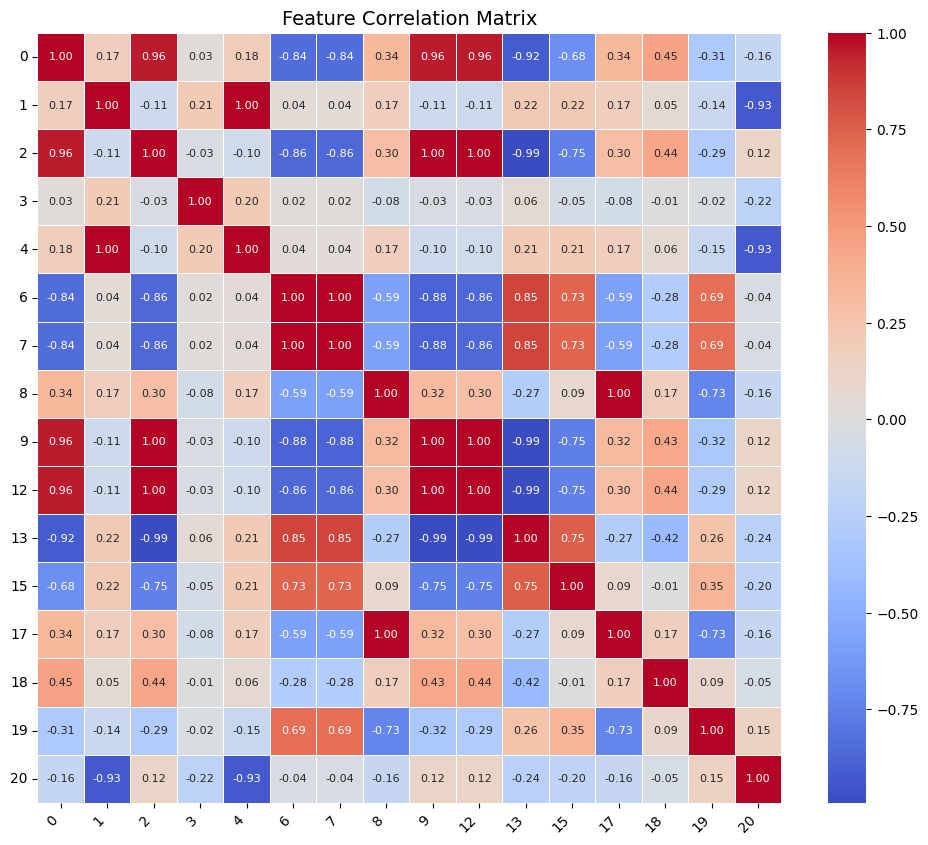

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df_train.corr().fillna(0)

plt.figure(figsize=(12, 10)) 

sns.heatmap(
    correlation_matrix, 
    annot=True,  
    fmt=".2f",  
    cmap="coolwarm", 
    linewidths=0.5,
    annot_kws={"size": 8}  
)

plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0) 

plt.title("Feature Correlation Matrix", fontsize=14)

plt.show()

In [17]:
# import numpy as np

# corr_matrix = df_train.corr().abs()  # Get absolute correlation values

# upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]

# df_train = df_train.drop(columns=to_drop)
# df_test = df_test.drop(columns=to_drop)
# df_val = df_val.drop(columns=to_drop)

# print(f"Dropped highly correlated columns: {to_drop}")

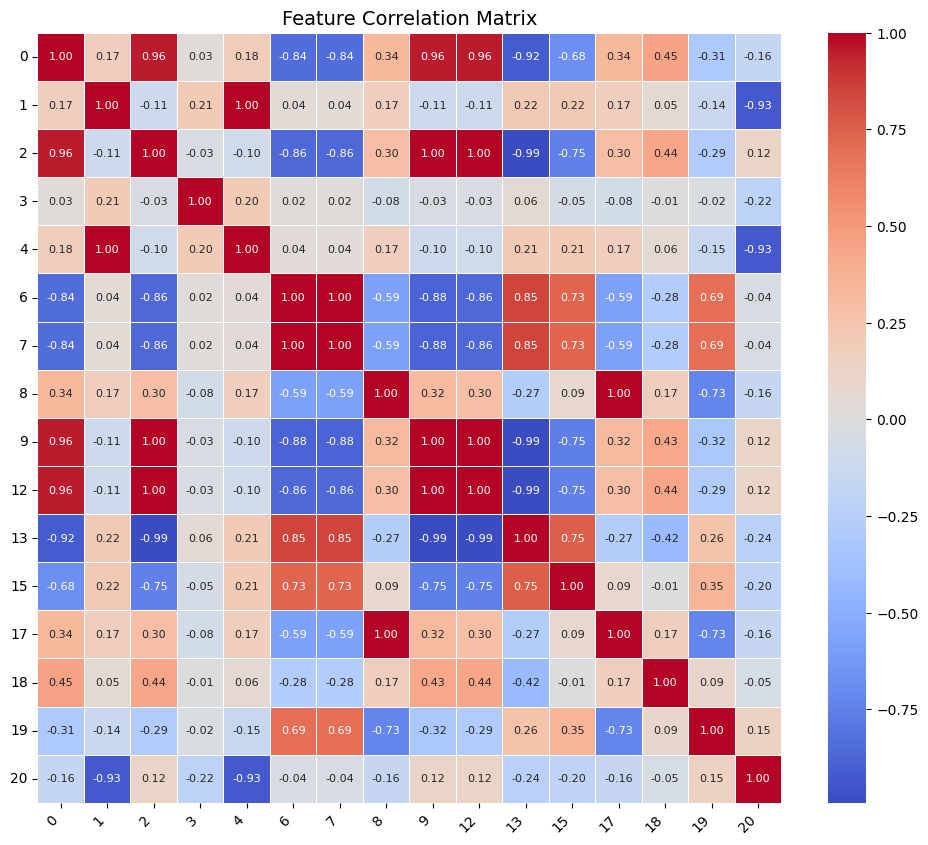

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df_train.corr().fillna(0)

plt.figure(figsize=(12, 10)) 

sns.heatmap(
    correlation_matrix, 
    annot=True,  
    fmt=".2f",  
    cmap="coolwarm", 
    linewidths=0.5,
    annot_kws={"size": 8}  
)

plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0) 

plt.title("Feature Correlation Matrix", fontsize=14)

plt.show()

In [19]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn import linear_model
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(df_train)

# model = linear_model.LassoLarsCV(cv=10, max_n_alphas=100).fit(X_train_scaled, df_train_labels['label'].values)

# fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

# cm = iter(plt.get_cmap("tab10")(np.linspace(0, 1, df_train.shape[1])))

# for i in range(df_train.shape[1]):
#     c = next(cm)
#     ax.plot(model.alphas_, model.coef_path_.T[:, i], c=c, alpha=0.8, label=df_train.columns[i])

# ax.axvline(model.alpha_, linestyle="--", c='k', label="Optimal Alpha (CV)")

# ax.set_xscale("log")

# ax.set_xlabel("Alpha")
# ax.set_ylabel("Coefficient Values")
# ax.set_title("Lasso Regression - High Resolution Feature Importance Paths")

# ax.legend(loc="upper right", fontsize="small", ncol=3, frameon=True)

# plt.show()

# zero_coef_features = df_train.columns[np.where(model.coef_ == 0)[0]]
# positive_coef_features = df_train.columns[np.where(model.coef_ > 0)[0]]

# print("Features with zero coefficients:", zero_coef_features.tolist())
# print("Features with positive coefficients:", positive_coef_features.tolist())

In [20]:
# import matplotlib.pyplot as plt
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.feature_selection import RFECV
# from sklearn.model_selection import StratifiedKFold

# clf = RandomForestClassifier(n_estimators=10000, random_state=42)

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# selector = RFECV(estimator=clf, step=1, cv=cv, scoring='accuracy')
# selector.fit(df_train, df_train_labels['label'])

# plt.figure(figsize=(8, 6))
# plt.xlabel("Number of Features Selected")
# plt.ylabel("Cross Validation Score (Accuracy)")
# plt.plot(range(1, len(selector.cv_results_['mean_test_score']) + 1),
#          selector.cv_results_['mean_test_score'])
# plt.title("Recursive Feature Elimination with Cross-Validation")
# plt.show()

# selected_features = df_train.columns[selector.support_]
# print("Selected Features:", selected_features.tolist())

## features extraction

In [21]:
df_train = df_train.fillna(0)
df_test = df_test.fillna(0)
df_val = df_val.fillna(0)

In [22]:
# from sklearn.decomposition import PCA

# pca = PCA(n_components=0.95)
# df_train = pca.fit_transform(df_train)
# df_val = pca.transform(df_val)
# df_test = pca.transform(df_test)

# num_components = pca.n_components_
# print(f"Number of components selected to retain 95% variance: {num_components}")

## training

In [23]:
df_train = pd.DataFrame(df_train)
df_val = pd.DataFrame(df_val)
df_test = pd.DataFrame(df_test)

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

In [25]:
def display_results(y_test, y_pred, y_pred_proba):

    classification_rep = classification_report(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_rep)
    
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()
    
    if len(rf_classifier.classes_) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
        roc_auc = auc(fpr, tpr)
    
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characteristic (ROC) Curve")
        plt.legend(loc="lower right")
        plt.show()
    
    elif len(rf_classifier.classes_) > 2:
        y_test_bin = label_binarize(y_test, classes=rf_classifier.classes_)
        fpr, tpr, roc_auc = {}, {}, {}
    
        for i in range(len(rf_classifier.classes_)):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
    
        plt.figure(figsize=(6, 5))
        for i in range(len(rf_classifier.classes_)):
            plt.plot(fpr[i], tpr[i], lw=2, label=f"Class {rf_classifier.classes_[i]} (AUC = {roc_auc[i]:.2f})")
    
        plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Multi-Class ROC Curve")
        plt.legend(loc="lower right")
        plt.show()

## Random Forest

Accuracy: 0.1850
Classification Report:
              precision    recall  f1-score   support

           0       0.05      0.05      0.05        20
           1       0.29      0.25      0.27        20
           2       0.10      0.05      0.07        20
           3       0.07      0.10      0.08        20
           4       0.19      0.25      0.22        20
           5       0.25      0.10      0.14        20
           6       0.44      0.35      0.39        20
           7       0.19      0.20      0.20        20
           8       0.30      0.30      0.30        20
           9       0.12      0.20      0.15        20

    accuracy                           0.18       200
   macro avg       0.20      0.18      0.19       200
weighted avg       0.20      0.18      0.19       200



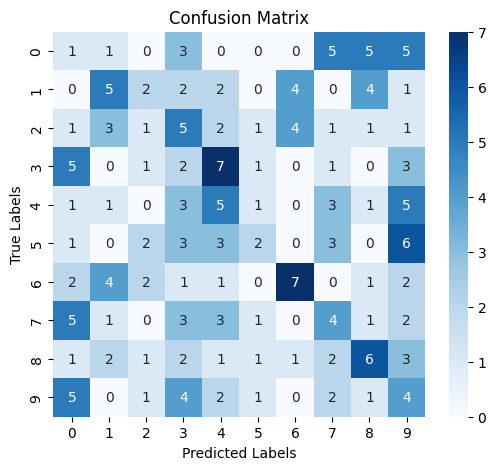

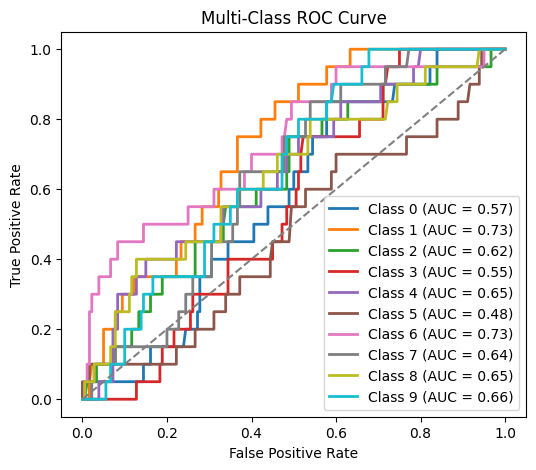

In [26]:
from sklearn.ensemble import RandomForestClassifier

X_train = df_train
y_train = df_train_labels["label"]

X_test = df_test
y_test = df_test_labels["label"]

rf_classifier = RandomForestClassifier(n_estimators=10000, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)
    
accuracy = accuracy_score(y_test, y_pred)

display_results(y_test, y_pred, y_pred_proba)

## SVM

/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

Accuracy: 0.1850
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.19      0.50      0.28        20
           2       0.00      0.00      0.00        20
           3       0.19      0.25      0.22        20
           4       0.20      0.15      0.17        20
           5       0.21      0.20      0.21        20
           6       0.00      0.00      0.00        20
           7       0.00      0.00      0.00        20
           8       0.33      0.05      0.09        20
           9       0.10      0.30      0.15        20

    accuracy                           0.14       200
   macro avg       0.12      0.15      0.11       200
weighted avg       0.12      0.14      0.11       200



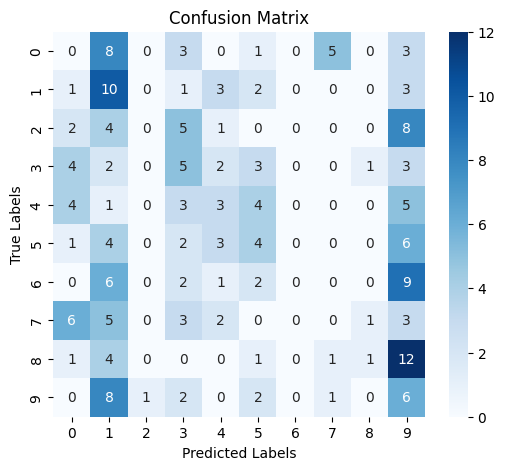

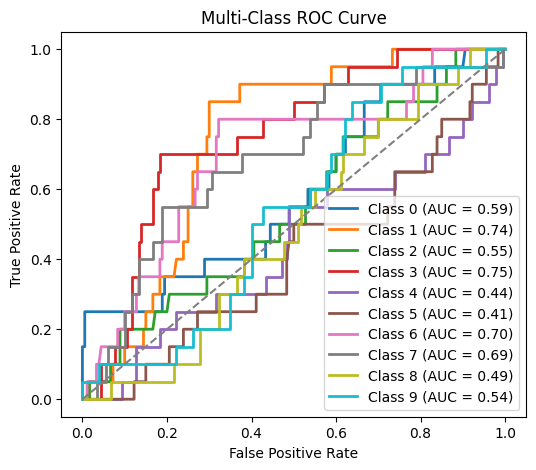

In [27]:
from sklearn.svm import SVC

X_train = df_train
y_train = df_train_labels["label"]

X_test = df_test
y_test = df_test_labels["label"]

svm_classifier = SVC(kernel="rbf", probability=True, random_state=42)
svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)
y_pred_proba = svm_classifier.predict_proba(X_test)

display_results(y_test, y_pred, y_pred_proba)

## KNN

Accuracy: 0.1850
Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.40      0.24        20
           1       0.19      0.35      0.25        20
           2       0.12      0.10      0.11        20
           3       0.12      0.15      0.14        20
           4       0.14      0.15      0.15        20
           5       0.00      0.00      0.00        20
           6       0.20      0.05      0.08        20
           7       0.13      0.10      0.11        20
           8       0.12      0.05      0.07        20
           9       0.05      0.05      0.05        20

    accuracy                           0.14       200
   macro avg       0.13      0.14      0.12       200
weighted avg       0.13      0.14      0.12       200



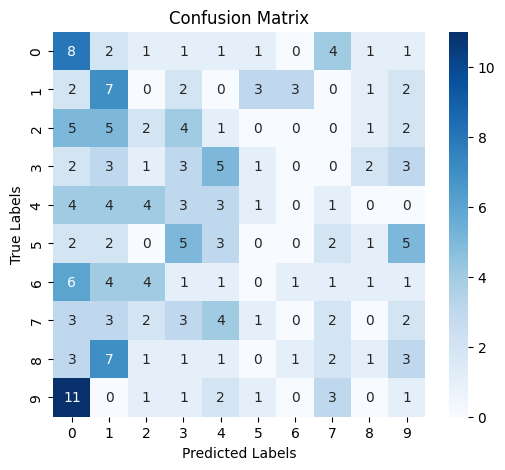

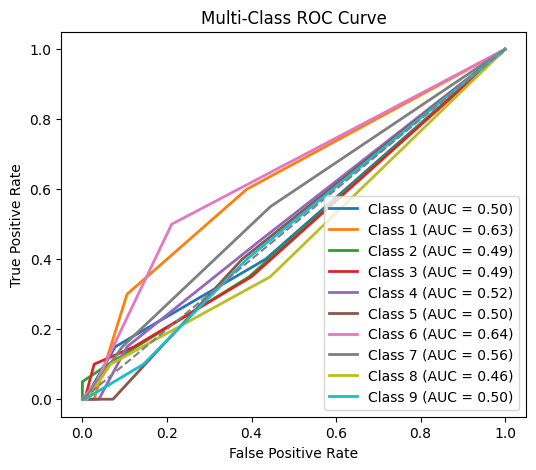

In [28]:
from sklearn.neighbors import KNeighborsClassifier

X_train = df_train
y_train = df_train_labels["label"]

X_test = df_test
y_test = df_test_labels["label"]

knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train, y_train)

y_pred = knn_classifier.predict(X_test)
y_pred_proba = knn_classifier.predict_proba(X_test)

display_results(y_test, y_pred, y_pred_proba)

## Naive Bayes

/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

Accuracy: 0.1850
Classification Report:
              precision    recall  f1-score   support

           0       0.14      0.10      0.12        20
           1       0.21      0.45      0.29        20
           2       0.00      0.00      0.00        20
           3       0.12      0.15      0.13        20
           4       0.00      0.00      0.00        20
           5       0.33      0.05      0.09        20
           6       0.19      0.30      0.24        20
           7       0.04      0.05      0.05        20
           8       0.15      0.10      0.12        20
           9       0.13      0.30      0.18        20

    accuracy                           0.15       200
   macro avg       0.13      0.15      0.12       200
weighted avg       0.13      0.15      0.12       200



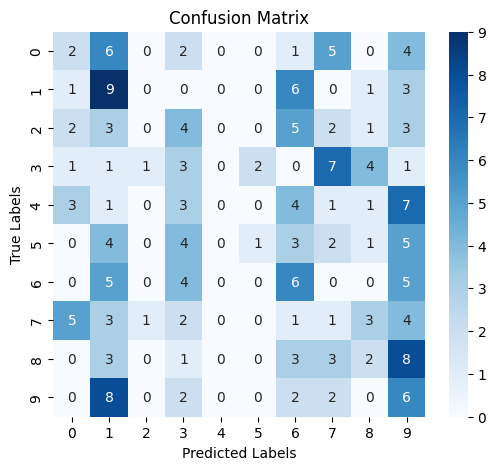

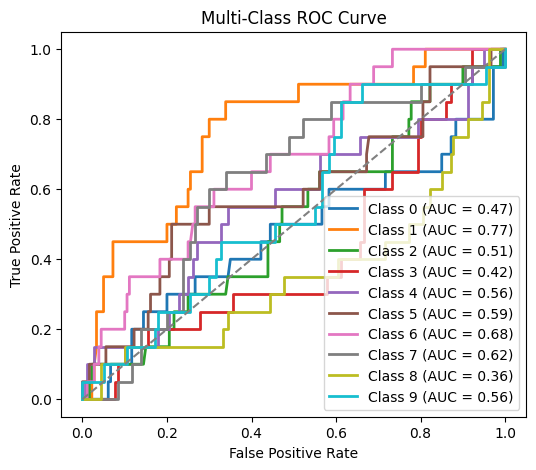

In [29]:
from sklearn.naive_bayes import GaussianNB

X_train = df_train
y_train = df_train_labels["label"]

X_test = df_test
y_test = df_test_labels["label"]

nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)
y_pred_proba = nb_classifier.predict_proba(X_test)

display_results(y_test, y_pred, y_pred_proba)

## Logistic Regression

/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

Accuracy: 0.1850
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.26      0.45      0.33        20
           2       0.00      0.00      0.00        20
           3       0.14      0.15      0.15        20
           4       0.00      0.00      0.00        20
           5       0.00      0.00      0.00        20
           6       0.32      0.35      0.33        20
           7       0.08      0.10      0.09        20
           8       0.03      0.05      0.04        20
           9       0.10      0.30      0.15        20

    accuracy                           0.14       200
   macro avg       0.09      0.14      0.11       200
weighted avg       0.09      0.14      0.11       200



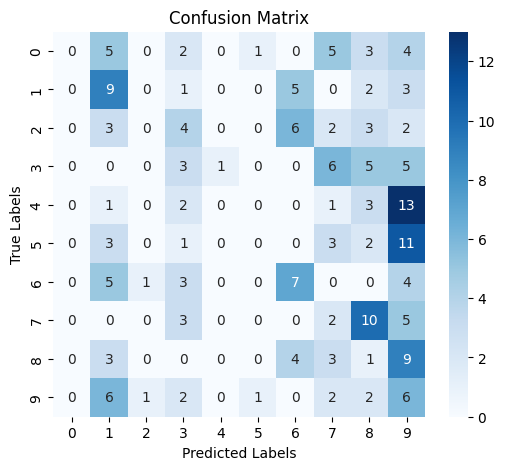

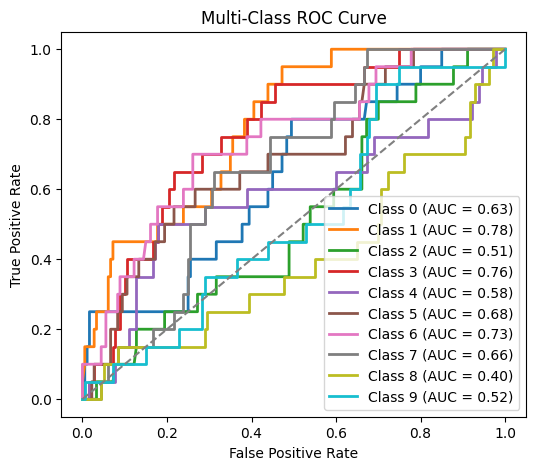

In [30]:
from sklearn.linear_model import LogisticRegression

X_train = df_train
y_train = df_train_labels["label"]

X_test = df_test
y_test = df_test_labels["label"]

logreg_classifier = LogisticRegression(max_iter=10000, random_state=42)
logreg_classifier.fit(X_train, y_train)

y_pred = logreg_classifier.predict(X_test)
y_pred_proba = logreg_classifier.predict_proba(X_test)

display_results(y_test, y_pred, y_pred_proba)

## Decision Tree

Accuracy: 0.1850
Classification Report:
              precision    recall  f1-score   support

           0       0.05      0.05      0.05        20
           1       0.16      0.20      0.18        20
           2       0.07      0.05      0.06        20
           3       0.00      0.00      0.00        20
           4       0.19      0.25      0.21        20
           5       0.06      0.05      0.06        20
           6       0.23      0.25      0.24        20
           7       0.18      0.25      0.21        20
           8       0.11      0.10      0.11        20
           9       0.23      0.25      0.24        20

    accuracy                           0.14       200
   macro avg       0.13      0.15      0.13       200
weighted avg       0.13      0.14      0.13       200



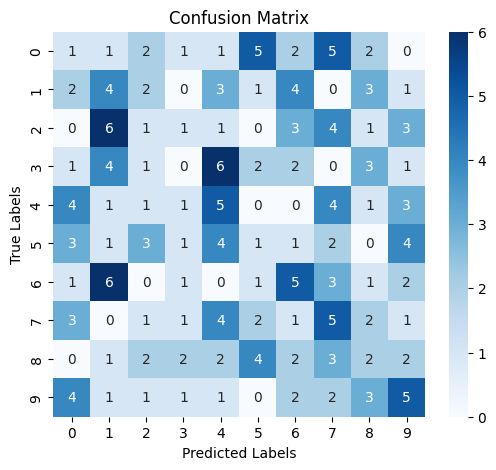

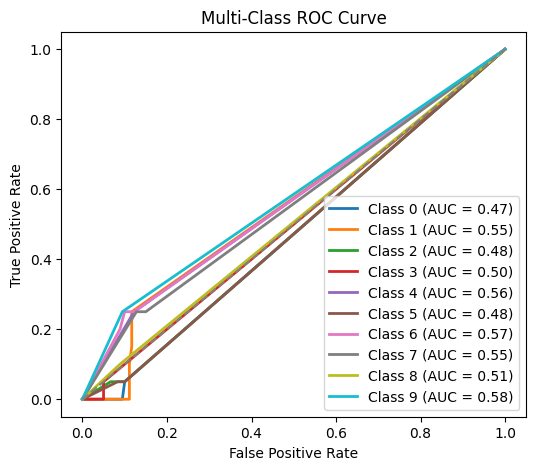

In [31]:
from sklearn.tree import DecisionTreeClassifier

X_train = df_train
y_train = df_train_labels["label"]

X_test = df_test
y_test = df_test_labels["label"]

dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

y_pred = dt_classifier.predict(X_test)
y_pred_proba = dt_classifier.predict_proba(X_test)

display_results(y_test, y_pred, y_pred_proba)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

def display_decision_tree(classifier, feature_names):
    plt.figure(figsize=(15, 10))
    plot_tree(
        classifier, 
        feature_names=feature_names, 
        class_names=classifier.classes_.astype(str), 
        filled=True, 
        rounded=True
    )
    plt.show()

display_decision_tree(dt_classifier, feature_names=df_train.columns)

## XGBoost

In [ ]:
from xgboost import XGBClassifier

X_train = df_train
y_train = df_train_labels["label"]

X_test = df_test
y_test = df_test_labels["label"]

xgb_classifier = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_classifier.fit(X_train, y_train)

y_pred = xgb_classifier.predict(X_test)
y_pred_proba = xgb_classifier.predict_proba(X_test)

display_results(y_test, y_pred, y_pred_proba)

# Deep Learning

In [ ]:
import torch
import numpy as np
import random

def set_seed(seed=0):
    torch.manual_seed(seed)  # Sets PyTorch seed (CPU)
    torch.cuda.manual_seed(seed)  # Sets PyTorch seed (GPU)
    torch.cuda.manual_seed_all(seed)  # If using multi-GPU
    np.random.seed(seed)  # Sets NumPy seed
    random.seed(seed)  # Sets Python random seed

    torch.backends.cudnn.deterministic = True  # Ensures deterministic behavior
    torch.backends.cudnn.benchmark = False  # Disables cuDNN optimization for reproducibility

set_seed(0)  # Set seed to 0

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

X_train = torch.tensor(df_train.values, dtype=torch.float32)
y_train = torch.tensor(df_train_labels["label"].values, dtype=torch.long)

X_test = torch.tensor(df_test.values, dtype=torch.float32)
y_test = torch.tensor(df_test_labels["label"].values, dtype=torch.long)

X_val = torch.tensor(df_val.values, dtype=torch.float32)
y_val = torch.tensor(df_val_labels["label"].values, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import numpy as np

class NN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NN, self).__init__()
        
        # Best hyperparameters from Optuna
        neurons = np.array([512, 512, 256, 512])
        dropout_rate = 0.22830940644606096

        # Layers
        self.fc1 = nn.Linear(input_size, neurons[0])
        self.fc2 = nn.Linear(neurons[0], neurons[1])
        self.fc3 = nn.Linear(neurons[1], neurons[2])
        self.fc4 = nn.Linear(neurons[2], neurons[3])
        self.fc5 = nn.Linear(neurons[3], num_classes)  # No activation in last layer

        # Activation and dropout
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc4(x)
        x = self.relu(x)

        x = self.fc5(x)  # Last layer has no activation (logits)

        # Apply activation based on number of classes
        if num_classes == 2:
            x = torch.sigmoid(x)
        else:
            x = torch.softmax(x, dim=1)

        return x  # Final output


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import optuna
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define Dynamic Neural Network with tunable parameters
class DynamicNN(nn.Module):
    def __init__(self, input_size, num_classes, neurons_per_layer, dropout, dropout_layers):
        super(DynamicNN, self).__init__()
        layers = []
        prev_neurons = input_size

        for i, neurons in enumerate(neurons_per_layer):
            layers.append(nn.Linear(prev_neurons, neurons))
            layers.append(nn.ReLU())

            # Apply dropout only for layers specified in dropout_layers
            if i in dropout_layers:
                layers.append(nn.Dropout(dropout))
                
            prev_neurons = neurons

        layers.append(nn.Linear(prev_neurons, num_classes))  # Final output layer

        self.model = nn.Sequential(*layers)
        self.num_classes = num_classes

    def forward(self, x):
        x = self.model(x)

        # Apply final activation function based on number of classes
        if self.num_classes == 2:
            return torch.sigmoid(x)
        else:
            return torch.softmax(x, dim=1)

# Function to check and convert data type
def to_tensor(data, dtype, device):
    if isinstance(data, np.ndarray):
        return torch.tensor(data, dtype=dtype, device=device)
    elif isinstance(data, torch.Tensor):
        return data.clone().detach().to(dtype).to(device)
    else:
        raise TypeError(f"Unsupported data type: {type(data)}")

# Function to train and evaluate model with given hyperparameters
def objective(trial):
    # Hyperparameter search space
    num_layers = trial.suggest_int("num_layers", 1, 10)
    neurons_per_layer = [trial.suggest_categorical(f"neurons_l{i}", [64, 128, 256, 512]) for i in range(num_layers)]
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    dropout_layers = trial.suggest_categorical("dropout_layers", [[0], [1], [2], [0, 2], [1, 3], []])  # Different dropout placements
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)

    # Initialize model
    model = DynamicNN(input_size=X_train.shape[1], num_classes=len(np.unique(y_train)),
                      neurons_per_layer=neurons_per_layer, dropout=dropout, dropout_layers=dropout_layers).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    # Prepare DataLoader (Fixing tensor conversion)
    X_train_tensor = to_tensor(X_train, dtype=torch.float32, device=device)
    y_train_tensor = to_tensor(y_train, dtype=torch.long, device=device)
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)

    # Train model
    model.train()
    for epoch in range(10):  # Train for 10 epochs
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    # Evaluate on test set
    model.eval()
    X_test_tensor = to_tensor(X_test, dtype=torch.float32, device=device)
    y_test_tensor = to_tensor(y_test, dtype=torch.long, device=device)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy  # Optuna will try to maximize this

# Run Optuna optimization
study = optuna.create_study(direction="maximize")  # We want to maximize accuracy
study.optimize(objective, n_trials=20)  # Perform 20 trials

# Best hyperparameters
print("Best Hyperparameters:", study.best_params)

# Visualization of results
fig, ax = plt.subplots(figsize=(8, 5))

# Plot accuracy over trials
ax.plot(study.trials_dataframe()["value"], marker="o", linestyle="-", color="b")
ax.set_title("Optimization Progress")
ax.set_xlabel("Trial")
ax.set_ylabel("Accuracy")

plt.show()

# Optuna built-in visualizations
optuna.visualization.plot_param_importances(study).show()
optuna.visualization.plot_optimization_history(study).show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

# Initialize Model
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model
model = NN(input_size=X_train.shape[1], num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0006075873017020676, weight_decay=1e-5)

# Training Loop
def train_model(model, train_loader, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Train Model
train_model(model, train_loader, num_epochs=10)

# Function to evaluate model and display confusion matrix
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Test the model and show confusion matrix
evaluate_model(model, test_loader)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from torch.utils.data import Dataset, DataLoader

# Model Setup
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NN(input_size=X_train.shape[1], num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

# Training with Early Stopping & AUC-ROC Monitoring
def train_model(model, train_loader, val_loader, num_epochs=50, patience=5):
    best_auc_roc = 0.0
    patience_counter = 0
    best_model_path = "best_model.pth"

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_accuracy = 100 * correct / total
        val_auc_roc = evaluate_auc_roc(model, val_loader, num_classes)  # Compute AUC-ROC

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss:.4f} - Train Acc: {train_accuracy:.2f}% - Val AUC-ROC: {val_auc_roc:.4f}")

        # Early Stopping Logic
        if val_auc_roc > best_auc_roc:
            best_auc_roc = val_auc_roc
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)  # Save Best Model
            print(f"✅ New Best Model Saved! AUC-ROC: {best_auc_roc:.4f}")
        else:
            patience_counter += 1
            print(f"⏳ Early Stopping Counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"⏹️ Early Stopping Triggered! Best AUC-ROC: {best_auc_roc:.4f}")
            break

    print("🎉 Training Complete!")

from sklearn.preprocessing import label_binarize

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import numpy as np

def evaluate_auc_roc(model, val_loader, num_classes):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()  # Ensure valid probabilities

            all_preds.extend(probabilities)
            all_labels.extend(y_batch.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 🔍 Debugging NaN values
    if np.isnan(all_preds).sum() > 0 or np.isnan(all_labels).sum() > 0:
        print("⚠️ Warning: NaN values detected in predictions or labels.")
        all_preds = np.nan_to_num(all_preds)  # Replace NaNs with 0
        all_labels = np.nan_to_num(all_labels)

    # Ensure at least two unique classes exist
    if len(set(all_labels)) == 1:
        print("⚠️ Warning: Only one class present in all_labels. AUC-ROC cannot be computed.")
        return 0.0

    # Compute AUC-ROC
    all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))

    try:
        if num_classes > 2:
            return roc_auc_score(all_labels_bin, all_preds, multi_class='ovo')
        else:
            return roc_auc_score(all_labels, all_preds[:, 1])  # Binary AUC-ROC
    except ValueError as e:
        print(f"❌ Error in AUC-ROC computation: {e}")
        return 0.0  # Return default value if an error occurs


# Train Model
train_model(model, train_loader, val_loader, num_epochs=50, patience=5)

# Load Best Model and Evaluate on Test Set
best_model = NN(input_size=X_train.shape[1], num_classes=num_classes).to(device)
best_model.load_state_dict(torch.load("best_model.pth"))
best_model.eval()

from sklearn.metrics import precision_recall_fscore_support

from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def evaluate_model(model, test_loader, num_classes):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)

            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()  # Ensure valid probabilities
            _, predicted = torch.max(outputs, 1)  # Predicted class

            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            all_probs.extend(probabilities)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # 🔍 Check for NaN values
    if np.isnan(all_probs).sum() > 0 or np.isnan(all_labels).sum() > 0:
        print("⚠️ Warning: NaN values detected in predictions or labels. Replacing NaNs with zeros.")
        all_probs = np.nan_to_num(all_probs)
        all_labels = np.nan_to_num(all_labels)

    # 🔍 Ensure at least two unique classes exist
    if len(set(all_labels)) == 1:
        print("⚠️ Warning: Only one class present in all_labels. AUC-ROC and multi-class metrics cannot be computed.")
        auc_roc = 0.0
    else:
        # Compute AUC-ROC
        all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))
        try:
            if num_classes > 2:
                auc_roc = roc_auc_score(all_labels_bin, all_probs, multi_class='ovo')
            else:
                auc_roc = roc_auc_score(all_labels, all_probs[:, 1])  # Binary AUC-ROC
        except ValueError as e:
            print(f"❌ Error in AUC-ROC computation: {e}")
            auc_roc = 0.0

    # Compute Accuracy
    accuracy = 100 * correct / total if total > 0 else 0.0

    # Compute Precision, Recall, F1-score for each class
    try:
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0)
        macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
        weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    except ValueError as e:
        print(f"❌ Error in Precision/Recall/F1 computation: {e}")
        precision, recall, f1 = [0] * num_classes, [0] * num_classes, [0] * num_classes
        macro_precision, macro_recall, macro_f1 = 0.0, 0.0, 0.0
        weighted_precision, weighted_recall, weighted_f1 = 0.0, 0.0, 0.0

    # Print evaluation results
    print(f"\n✅ Test Accuracy: {accuracy:.2f}%")
    print(f"✅ Test AUC-ROC: {auc_roc:.4f}\n")

    print(f"📊 Macro Avg - Precision: {macro_precision:.4f}, Recall: {macro_recall:.4f}, F1-score: {macro_f1:.4f}")
    print(f"📊 Weighted Avg - Precision: {weighted_precision:.4f}, Recall: {weighted_recall:.4f}, F1-score: {weighted_f1:.4f}")

    # Display Per-Class Metrics
    for i in range(num_classes):
        print(f"🔹 Class {i} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1-score: {f1[i]:.4f}")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    print("\n📌 Classification Report:\n", classification_report(all_labels, all_preds, digits=4))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


# Evaluate Best Model
evaluate_model(best_model, test_loader, num_classes)
